# PyCellMech Analysis of PUMA Dataset

This notebook analyzes radiomics features extracted from the PUMA (Panoptic segmentation of nuclei and tissues in pathology images for melanoma) dataset. Features are calculated from the CSV outputs of the Pycellmech pipeline.

## Download Example Data

This notebook uses 206 tiles from the PUMA dataset. The data includes:
- H&E image tiles (1024x1024 pixels)
- Nuclei annotations (GeoJSON ground truth)

**Data source**: [PUMA Grand Challenge](https://puma.grand-challenge.org/, https://zenodo.org/records/14869398)

In [1]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import GroupKFold, cross_val_predict, train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from collections import Counter

gt_pycell_dir = "/home/user/Music/analysis_puma/ground_truth/pycell_features_csv"
output_dir = "/home/user/Music/analysis_puma/ground_truth/article_figures"
os.makedirs(output_dir, exist_ok=True)

file_pattern = "training_set_*_roi_*_nuclei_features.csv"

correlation_threshold = 0.90
n_top_features = 10

In [3]:
# Functions to clean/process the data

def _drop_constant_cols(df: pd.DataFrame, eps: float = 1e-12) -> pd.DataFrame:
    """Drop columns with zero or near-zero variance."""
    nunique = df.nunique(dropna=True)
    keep = nunique[nunique > 1].index
    df = df[keep]
    var = df.var(axis=0, ddof=0)
    return df.loc[:, var.fillna(0.0) > eps]

def compute_feature_importance(X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
    """Compute feature importance using MI, ANOVA, and RF."""
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    X_filled = X.fillna(X.median())
    
    results = pd.DataFrame(index=X.columns)
    
    # Mutual Information
    mi_scores = mutual_info_classif(X_filled, y_enc, random_state=0, n_neighbors=5)
    results['MutualInfo'] = mi_scores
    
    # ANOVA F-test
    f_scores, _ = f_classif(X_filled, y_enc)
    results['ANOVA_F'] = np.nan_to_num(f_scores, nan=0)

    # Random Forest importance
    rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=0, n_jobs=-1)
    rf.fit(X_filled, y_enc)
    results['RF_Importance'] = rf.feature_importances_
    
    # Normalize and compute consensus
    for col in ['MutualInfo', 'ANOVA_F', 'RF_Importance']:
        max_val = results[col].max()
        results[col + '_norm'] = results[col] / max_val if max_val > 0 else 0
    
    norm_cols = [c for c in results.columns if c.endswith('_norm')]
    results['Consensus'] = results[norm_cols].mean(axis=1)
    return results.sort_values('Consensus', ascending=False)

def remap_cell_class(c: str) -> str:
    """Remap cell classes to tumor / lymphocyte / apoptosis / Other."""
    c_lower = c.lower()
    if 'nuclei_tumor' in c_lower:
        return 'tumor'
    elif 'nuclei_lymphocyte' in c_lower:
        return 'lymphocyte'
    elif 'nuclei_apoptosis' in c_lower:
        return 'apoptosis'
    else:
        return 'other'

def tile_id_from_path(p: str):
    """Extract tile ID from file path (PUMA format: training_set_*_roi_XXX_nuclei_features_*)."""
    basename = os.path.basename(p)

    m = re.search(r"_roi_(\d+)_nuclei_features", basename)
    if m:
        return int(m.group(1))

def load_radiomics_data(gt_pycell_dir, file_pattern):
    """Load radiomics CSVs, filter by date and object type."""
    all_csv = sorted(glob.glob(os.path.join(gt_pycell_dir, file_pattern)))
        
    print(f"Pycellmech feature files: {len(all_csv)}")
    
    if not all_csv:
        raise RuntimeError("No Pycellmech CSV files found!")
    
    dfs = []
    for f in all_csv:
        df = pd.read_csv(f)
        df["tile_id"] = tile_id_from_path(f)
        df["source_file"] = os.path.basename(f)
        dfs.append(df)
    
    data = pd.concat(dfs, ignore_index=True)
    data["label"] = data["label"].fillna("Unclassified")
        
    return data, all_csv

# Parse np.float64(...) string entries into clean Python float lists ───────
def parse_np_floats(val):
    if isinstance(val, str):
        # Grab every number sitting inside np.float64( ) or numpy.float64( )
        numbers = re.findall(
            r'(?:np|numpy)\.float64\(([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\)',
            val
        )
        return [float(n) for n in numbers]
    return val  # already a list or NaN — leave as-is


## Cell-level Radiomics Analysis

Analysis of radiomics features extracted from individual cell nuclei.


In [4]:
cells, files_cells = load_radiomics_data(
    gt_pycell_dir, file_pattern
)

print(f"\nRows (cells): {cells.shape}")
print(cells["label"].value_counts())

cells["simp_label"] = cells["label"].apply(remap_cell_class)

Pycellmech feature files: 206

Rows (cells): (97429, 40)
label
nuclei_tumor          57419
nuclei_lymphocyte     21643
nuclei_histiocyte      7168
nuclei_stroma          3856
nuclei_epithelium      2211
nuclei_apoptosis       1850
nuclei_endothelium     1701
nuclei_melanophage      695
nuclei_plasma_cell      520
nuclei_neutrophil       366
Name: count, dtype: int64


### Derive new features: average of area function, length of PEVD

In [5]:
# add area features
cells["area_function"] = cells["area_function"].apply(parse_np_floats)
print(cells["area_function"].iloc[0])

# area function (average of triangles between centroid and points on contour) 
if {'area_function_avg', 'area_function_var', 'mbr_area'}.issubset(cells.columns) == False:
    cells.insert(loc = 11, column = "area_function_avg", value = cells["area_function"].apply(np.mean))
    cells.insert(loc = 12, column = "area_function_var", value = cells["area_function"].apply(np.mean))
    cells.insert(loc = 24, column = "mbr_area", value = cells['mbr_width']*cells['mbr_height'])

print(cells[["area_function_avg", "area_function_var", 'mbr_area']].head())

# find length of PEVD, i.e. number of coordinates in polygon approximation

def parse_coord_list(val):
    if isinstance(val, str):
        # Match each [x   y] pair regardless of how many spaces separate the numbers
        pairs = re.findall(r'\[\s*(-?\d+)\s+(-?\d+)\s*\]', val)
        return [[int(a), int(b)] for a, b in pairs]
    return val  # already a list — leave as-is

# Apply to PEVD column
cells["pevd"] = cells["pevd"].apply(parse_coord_list)
cells['len_pevd']=(cells["pevd"].apply(len))
cells.head()

[2.5375000000000227, 18.700000000000045, 3.5375000000000227, 35.40000000000009, 5.537500000000023, 8.350000000000023, 6.037500000000023, 7.850000000000023, 6.537500000000023, 7.350000000000023, 7.037500000000023, 6.850000000000023, 7.537500000000023, 6.350000000000023, 16.075000000000045, 5.350000000000023, 8.537500000000023, 4.850000000000023, 9.037500000000023, 4.350000000000023, 9.537500000000023, 3.8500000000000227, 50.187500000000114, 8.6875, 19.075000000000045, 9.6875, 9.037500000000023, 10.1875, 8.537500000000023, 10.6875, 8.037500000000023, 11.1875, 7.537500000000023, 35.062499999999986, 6.037500000000023, 48.75, 20.337499999999977, 23.375, 21.337499999999977, 11.1875, 21.837499999999977, 11.149999999999977, 42.674999999999955, 36.44999999999993, 19.837499999999977, 113.84999999999978, 9.962499999999977, 24.299999999999955, 21.924999999999955, 11.149999999999977, 57.312499999999886, 2.8125, 10.962499999999977, 7.649999999999977, 3.8125, 43.84999999999991, 5.8125, 20.92499999999

,_name,contour_number,object_id,label,centroid_x,centroid_y,complex_coordinates,cdf,tangent_angles,curvature,...,pevd,sm,mpp,km_cc,km_ls,km_labels,tile_id,source_file,simp_label,len_pevd
0,training_set_metastatic_roi_001_nuclei.geojson,0,77797017-2159-4289-be43-1c6ad5e07780,nuclei_tumor,879.375000,780.700000,"[np.complex128(14.625-19.700000000000045j), np...","[np.float64(24.5352934565699), np.float64(23.1...","[0, np.float64(2.356194490192345), np.float64(...","[np.float64(0.35355339059327373), np.float64(0...",...,"[[894, 0], [891, 1], [890, 2], [886, 2], [885,...","[(0, 3), (3, 4), (4, 14), (14, 15), (15, 22), ...",[[894 761]\n [895 784]\n [894 761]],[[892.56 764.76 ]\n [863.76470588 8...,"[(array([876.95894516, 764.97149699]), array([...",[1 1 3 1 1 1 3 3 1 1 3 3 1 3 3 1 3 3 1 3 3 1 1...,1,training_set_metastatic_roi_001_nuclei_feature...,tumor,79
1,training_set_metastatic_roi_001_nuclei.geojson,1,8f274ae1-f95a-4bb0-9fa6-17eacaa0fa43,nuclei_tumor,661.306122,392.816327,[np.complex128(3.693877551020364-17.8163265306...,"[np.float64(18.19522526398971), np.float64(17....","[0, np.float64(2.356194490192345), np.float64(...","[np.float64(0.8838834764831843), np.float64(0....",...,"[[665, 0], [659, 1], [658, 2], [657, 2], [655,...","[(0, 1), (1, 2), (2, 4), (4, 7), (7, 13), (13,...",[[665 375]],[[664.5 377.33333333]\n [656.3125 4...,"[(array([655.06050889, 377.0416792 ]), array([...",[3 3 3 3 1 1 3 3 1 3 3 1 1 1 1 0 0 1 1 0 0 1 0...,1,training_set_metastatic_roi_001_nuclei_feature...,tumor,48
2,training_set_metastatic_roi_001_nuclei.geojson,2,4a67f94e-d2fd-4f48-8567-22e406d78777,nuclei_tumor,206.205128,654.051282,[np.complex128(9.794871794871796-10.0512820512...,"[np.float64(14.034521165768382), np.float64(12...","[0, np.float64(2.356194490192345), np.float64(...","[np.float64(0.7071067811865475), np.float64(0....",...,"[[216, 0], [211, 1], [210, 2], [206, 2], [205,...","[(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6...",[[216 644]],[[198. 665.88888889]\n [213.22222222 6...,"[(array([190.07413355, 666.07970495]), array([...",[2 0 2 2 2 2 0 0 2 0 2 2 0 0 2 2 0 1 1 0 0 1 1...,1,training_set_metastatic_roi_001_nuclei_feature...,tumor,38
3,training_set_metastatic_roi_001_nuclei.geojson,3,d25afc68-9072-4e99-accf-c479ad3b2fc8,nuclei_tumor,264.437500,461.937500,"[np.complex128(6.5625-11.9375j), np.complex128...","[np.float64(13.622419480400682), np.float64(12...","[0, np.float64(2.356194490192345), np.float64(...","[np.float64(0.35355339059327373), np.float64(0...",...,"[[271, 0], [267, 2], [265, 2], [264, 3], [263,...","[(0, 1), (1, 4), (4, 10), (10, 11), (11, 12), ...",[[271 450]],[[263.30769231 453.38461538]\n [260.83333333 4...,"[(array([255.90271791, 456.78836047]), array([...",[3 3 3 3 3 3 3 3 3 3 3 3 1 0 0 0 0 1 0 1 0 1 0...,1,training_set_metastatic_roi_001_nuclei_feature...,tumor,45
4,training_set_metastatic_roi_001_nuclei.geojson,4,3fe8ce7c-83ac-4457-b641-769715ac8ad0,nuclei_tumor,166.731707,510.536585,[np.complex128(5.268292682926841-14.5365853658...,"[np.float64(15.46179879224057), np.float64(14....","[0, np.float64(2.356194490192345), np.float64(...","[np.float64(0.17677669529663687), np.float64(0...",...,"[[172, 0], [170, 1], [167, 4], [166, 4], [164,...","[(0, 3), (3, 8), (8, 9), (9, 10), (10, 11), (1...",[[172 496]],[[166.11111111 521.77777778]\n [169.61538462 4...,"[(array([159.97118663, 523.91731237]), array([...",[2 2 2 2 2 2 2 2 2 1 0 1 0 1 1 0 0 1 1 0 0 0 1...,1,training_set_metastatic_roi_001_nuclei_feature...,tumor,40


## Clean up dataframe for ML processing

If classes are unbalanced, resample the data for three-way classification. Run the following block and skip the block immediately below.

In [6]:
# disregard any cells that are not "tumor" or "lymphocyte"
mask_cells = cells["simp_label"].isin(["tumor", "lymphocyte", "apoptosis"])
cells_filt = cells[mask_cells].copy()

X_num = cells_filt.select_dtypes(include=[np.number])
X_num = _drop_constant_cols(X_num)
y = cells_filt['simp_label'].astype(str)

counts = Counter(y)
print(counts)

# ---- Decide target counts ----
target_ratios = {'tumor': 0.60, 'lymphocyte': 0.30, 'apoptosis': 0.1}

# how much are you willing to duplicate apoptosis? e.g. 4x
oversample_factor = 3
target_apoptosis = counts['apoptosis'] * oversample_factor

# total dataset size implied by that apoptosis count + target ratio
total_target = target_apoptosis / target_ratios['apoptosis']

target_counts = {
    'apoptosis': int(target_apoptosis),
    'tumor': int(total_target * target_ratios['tumor']),
    'lymphocyte': int(total_target * target_ratios['lymphocyte']),
}
print(target_counts)

# sanity checks: tumor/lymphocyte targets must be <= original counts (since undersampling)
assert target_counts['tumor'] <= counts['tumor']
assert target_counts['lymphocyte'] <= counts['lymphocyte']
assert target_counts['apoptosis'] >= counts['apoptosis']

# ---- Step 1: oversample apoptosis only ----
over = RandomOverSampler(
    sampling_strategy={'apoptosis': target_counts['apoptosis']},
    random_state=42
)
X_resamp, y_resamp = over.fit_resample(X_num, y)
print("after oversampling:", Counter(y_resamp))

print(X_resamp)

# ---- Step 2: undersample tumor and lymphocyte ----
under = RandomUnderSampler(
    sampling_strategy={
        'tumor': target_counts['tumor'],
        'lymphocyte': target_counts['lymphocyte']
    },
    random_state=42
)
X_resamp, y_resamp = under.fit_resample(X_resamp, y_resamp)
print("after undersampling:", Counter(y_resamp))

# check final proportions
print(pd.Series(y_resamp).value_counts(normalize=True))

# remove the columns we don't want the model to extract patterns from, and drop those with constant values

X = X_resamp.drop(["contour_number", "centroid_x", "centroid_y", "tile_id"], axis=1)
y = y_resamp
tile_id = X_resamp['tile_id']
print(X.head())



Counter({'tumor': 57419, 'lymphocyte': 21643, 'apoptosis': 1850})
{'apoptosis': 5550, 'tumor': 33300, 'lymphocyte': 16650}
after oversampling: Counter({'tumor': 57419, 'lymphocyte': 21643, 'apoptosis': 5550})
       contour_number  centroid_x  centroid_y  area_function_avg  \
0                   0  879.375000  780.700000          16.905063   
1                   1  661.306122  392.816327          15.552083   
2                   2  206.205128  654.051282          13.210526   
3                   3  264.437500  461.937500          12.968085   
4                   4  166.731707  510.536585          13.225000   
...               ...         ...         ...                ...   
84607              93  971.818182  231.939394          12.187500   
84608             516  253.763158  140.815789          10.554054   
84609              21  605.444444   36.111111          29.000000   
84610             317  591.625000  339.562500           3.965726   
84611              27  821.750000  119.2083

In [50]:
# If not resampling (classes are fairly well-distributed), uncomment and run the block below.

''' # disregard any cells that are not "tumor" or "lymphocyte"
mask_cells = cells["simp_label"].isin(["tumor", "lymphocyte", "apoptosis"])
cells_filt = cells[mask_cells].copy()

X_num = cells_filt.select_dtypes(include=[np.number])
X_num = _drop_constant_cols(X_num)
y = cells_filt['simp_label'].astype(str)

X = X_num.drop(["contour_number", "centroid_x", "centroid_y", "tile_id"], axis=1)
tile_id = X_num['tile_id']
print(X.head())'''


   area_function_avg  area_function_var       abe     alpha    area  \
0          16.905063          16.905063 -0.056766 -0.598970  1335.5   
1          15.552083          15.552083 -0.073883 -1.197572   746.5   
2          13.210526          13.210526 -0.077794 -0.264326   502.0   
3          12.968085          12.968085 -0.087512 -0.582384   609.5   
4          13.225000          13.225000 -0.095318 -0.705306   529.0   

   eccentricity  mbr_width  mbr_height     mbr_area  mbr_angle     mbr_E  \
0      0.871103  58.243523   31.340561  1825.384669 -56.309933  0.538095   
1      0.708037  36.055511   25.238859   909.999977 -56.309933  0.700000   
2      0.869771  36.257843   19.622496   711.469367 -34.508522  0.541193   
3      0.843974  38.183762   20.506096   782.999877 -45.000000  0.537037   
4      0.857480  36.062447   19.091881   688.499932 -45.000000  0.529412   

   elongation  circularity_ratio        EV            EM   perimeter  \
0   -0.858407           0.705192  0.126118  

In [7]:
# replace N/A with median value
X_fill = X.apply(lambda s: s.fillna(s.median()), axis=0)
X = _drop_constant_cols(X_fill)

# split into training and test sets
X_train, X_test, y_train, y_test, tile_id_train, tile_id_test = train_test_split(X, y, tile_id, test_size=0.2, random_state=42)

### Compute feature importances based on Mutual Information, Random Forest, and ANOVA predictions

In [8]:
n_top_features = 10

print("Computing feature importance...")
importance_cells = compute_feature_importance(X_train, y_train)

top_features_cells = importance_cells.head(n_top_features).index.tolist()
print(f"\nTop {n_top_features} features by average importance:")
for i, f in enumerate(top_features_cells[:10], 1):
    print(f"  {i:2d}. {f}: {importance_cells.loc[f, 'Consensus']:.4f}")


Computing feature importance...

Top 10 features by average importance:
   1. perimeter: 0.9715
   2. mbr_width: 0.8650
   3. area: 0.7221
   4. mbr_area: 0.7073
   5. mbr_height: 0.4779
   6. area_function_avg: 0.4154
   7. area_function_var: 0.4000
   8. len_pevd: 0.3834
   9. circularity_ratio: 0.3615
  10. EM: 0.3541


In [9]:

top_features_cells
imp = importance_cells['Consensus']
importance_cells

,MutualInfo,ANOVA_F,RF_Importance,MutualInfo_norm,ANOVA_F_norm,RF_Importance_norm,Consensus
perimeter,0.265710,6594.906862,0.141003,1.000000,0.914581,1.000000,0.971527
mbr_width,0.216010,7210.849675,0.110266,0.812953,1.000000,0.782011,0.864988
area,0.211416,5050.116679,0.094526,0.795664,0.700350,0.670379,0.722131
mbr_area,0.224574,5045.526912,0.081361,0.845185,0.699713,0.577011,0.707303
mbr_height,0.154173,3891.864986,0.044246,0.580229,0.539723,0.313792,0.477915
area_function_avg,0.181652,812.207725,0.063435,0.683649,0.112637,0.449886,0.415390
area_function_var,0.181908,812.207725,0.056800,0.684610,0.112637,0.402828,0.400025
len_pevd,0.112996,3153.986066,0.040555,0.425260,0.437395,0.287619,0.383424
circularity_ratio,0.117601,1557.073665,0.060081,0.442591,0.215935,0.426097,0.361541
EM,0.236121,0.043308,0.024477,0.888642,0.000006,0.173593,0.354080


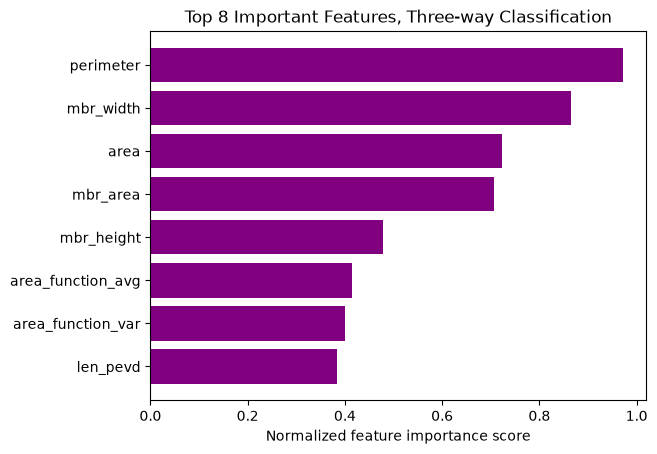

In [10]:
## plot feature importances

fig, ax = plt.subplots()

data = importance_cells['Consensus'][:8]
ax.barh(data.index, data, align='center', color = "purple")

ax.set_xlabel("Normalized feature importance score")
ax.invert_yaxis()
ax.set_title("Top 8 Important Features, Three-way Classification")

plt.show()

### Evaluate the performance of a three-way Random Forest classifier to differentiate between tumor, lymphocyte, and apoptosis

In [11]:
from sklearn.metrics import accuracy_score

n_splits = min(5, tile_id.nunique())
cv = GroupKFold(n_splits=n_splits)

print(f"=== Random Forest Classification ===")
print(f"Samples: {len(y_train)} | Features: {X_train.shape[1]} | CV folds: {n_splits}")
print(f"Classes: tumor ({(y_train=='tumor').sum()}), lymphocyte ({(y_train=='lymphocyte').sum()}), apoptosis ({(y_train=='apoptosis').sum()})")

# Random Forest
rf_cells = RandomForestClassifier(
    n_estimators=100, max_depth=15, min_samples_split=2,
    class_weight="balanced", random_state=42, n_jobs=-1
)

pred_rf_cells = cross_val_predict(rf_cells, X_train, y_train, cv=cv, groups=tile_id_train)

# Metrics
acc = accuracy_score(y_train, pred_rf_cells)
f1_rf_cells = f1_score(y_train, pred_rf_cells, average="macro")

print(f"\nAccuracy: {acc:.3f}")
print(f"Macro F1: {f1_rf_cells:.3f}")
print("\nClassification Report:")
print(classification_report(y_train, pred_rf_cells, zero_division=0))

pred_lookup = {}
for idx in range(len(pred_rf_cells)):
    tile_id = cells_filt.iloc[idx]["tile_id"]
    obj_id = cells_filt.iloc[idx]["object_id"]
    pred_lookup[(tile_id, obj_id)] = pred_rf_cells[idx]
print(f"\nPrediction lookup created with {len(pred_lookup)} entries")


=== Random Forest Classification ===
Samples: 44400 | Features: 18 | CV folds: 5
Classes: tumor (26664), lymphocyte (13311), apoptosis (4425)

Accuracy: 0.694
Macro F1: 0.602

Classification Report:
              precision    recall  f1-score   support

   apoptosis       0.49      0.32      0.39      4425
  lymphocyte       0.54      0.79      0.65     13311
       tumor       0.85      0.71      0.77     26664

    accuracy                           0.69     44400
   macro avg       0.63      0.61      0.60     44400
weighted avg       0.72      0.69      0.70     44400


Prediction lookup created with 44400 entries


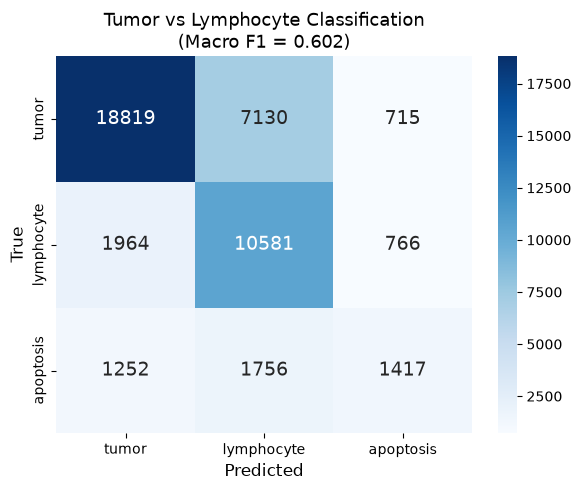

In [12]:
# Plot Random Forest results as a confusion matrix

classes_cells = ["tumor", "lymphocyte", "apoptosis"]

fig, ax = plt.subplots(figsize=(6, 5))

cm_rf = confusion_matrix(y_train, pred_rf_cells, labels=classes_cells)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", 
            xticklabels=classes_cells, yticklabels=classes_cells, ax=ax,
            annot_kws={"size": 14})
ax.set_title(f"Tumor vs Lymphocyte Classification\n(Macro F1 = {f1_rf_cells:.3f})", fontsize=13)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)

plt.tight_layout()
plt.show()
